---
# 3.1 Solving nonlinear equations
---

In many applications, one needs the solution to a **nonlinear equation** for which there is no closed formula.

- Suppose you do not have a cube-root function, but only the operations $+$, $-$, $\times$, $\div$:  

$$
x^3 = a
$$

- Polynomials with degree at least five have no general algebraic solution ([Abel-Ruffini Theorem](http://en.wikipedia.org/wiki/Abel%E2%80%93Ruffini_theorem)): 

$$
x^5 - 5x^4 + 5x^3 + 5x^2 - 6x - 1 = 0
$$

- General nonlinear equations:

$$
10\cosh(x/4) = x
\qquad \text{and} \qquad
2\cosh(x/4) = x
$$

**Note:** The **hyperbolic sine**, **hyperbolic cosine**, and **hyperbolic tangent** functions are defined as

$$
\sinh(t) = \frac{e^t - e^{-t}}{2},
\qquad
\cosh(t) = \frac{e^t + e^{-t}}{2},
\qquad
\tanh(t) = \frac{e^t - e^{-t}}{e^t + e^{-t}}.
$$

Thus $\tanh(t) = \frac{\sinh(t)}{\cosh(t)}$, $\frac{d}{dt} \sinh(t) = \cosh(t)$, $\frac{d}{dt} \cosh(t) = \sinh(t)$, and

$$
\cosh^2(t) - \sinh^2(t) = 1.
$$

The equation of the **unit hyperbola** is $x^2 - y^2 = 1$.

---

## Problem statement

Given $f \in C[a,b]$ (i.e., a *continuous* function $f \colon [a,b] \to \mathbb{R}$) and we want to find $x^* \in [a, b]$ such that

$$
f(x^*) = 0.
$$

The solution $x^*$ is called a **root** or **zero** of the function $f$. There could be exactly one root, many roots, or no roots at all.

In [1]:
f(x) = 10cosh(x/4) - x
g(x) = 2cosh(x/4) - x

g (generic function with 1 method)

In [2]:
# Plot the above functions and their roots

using Plots  # Package for plotting
using Roots  # Package for finding roots of functions
using LaTeXStrings

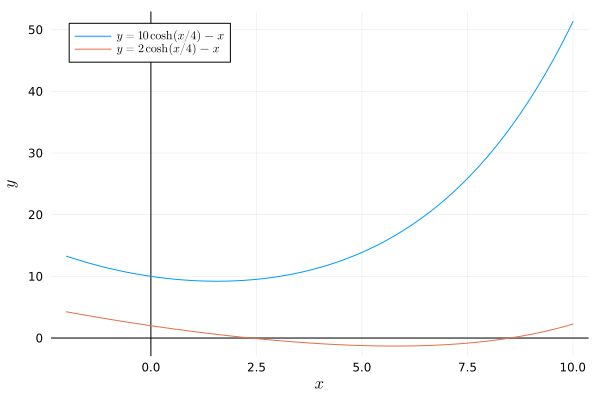

In [8]:
plot(axes_style=:zerolines, xlabel=L"x", ylabel=L"y")
plot!(f, -2, 10, label=L"y = 10\cosh(x/4) - x")
plot!(g, -2, 10, label=L"y = 2\cosh(x/4) - x")

In [ ]:
@doc find_zero

---

## Iterative methods

Often there is no closed formula for a root $x^*$ of the function $f$. Instead of using a formula to compute a root $x^*$, we will start with an **initial guess** $x_0$ and generate a **sequence of iterates**

$$ x_1, x_2, x_3, \ldots, x_k, \ldots $$

that we hope **converges** to $x^*$; i.e.,

$$\lim_{k \to \infty} x_k = x^*.$$

**Note:** Different initial guesses $x_0$ may generate sequences of iterates that converge to different roots. We will see how to deal with this issue.

---

## When to stop

Since the sequence of iterates is infinite, we must decide when we are close enough to a root $x^*$. However, we do not know $x^*$, so how can we decide when we are close enough?

Some options are to stop when:

1. The function value is small:

  $$\left|f(x_k)\right| < \mathtt{ftol}.$$
  
  A problem with this test is that $\left|f(x_k)\right|$ may be very small although $x_k$ is still very far from a root.
    
2. Consecutive iterates are very close to each other:

   $$\left|x_k - x_{k-1}\right| < \mathtt{atol}.$$
   
   A problem with this test is that `atol` must take into account the magnitude of the iterates.

3. Consecutive iterates are *relatively* close to each other:

   $$\left|x_k - x_{k-1}\right| < \mathtt{rtol} \left|x_k\right|.$$
   
   Usually this is more robust than the above absolute test.
   
Often a combination of the above conditions is used. For example, items 2 and 3 can be combined:   

$$\left|x_k - x_{k-1}\right| < \mathtt{tol}(1 + \left|x_k\right|).$$

---